In [32]:
import pandas as pd 
import numpy as np

PANEL_PATH = "/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta"
COEF_PATH = "/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv"


In [5]:
df = pd.read_stata(PANEL_PATH)

In [6]:
inc_col = "lgdppc_MA15" 

In [7]:
df_inc = df[[inc_col]].dropna()
q33 = df_inc[inc_col].quantile(1/3)
q66 

In [11]:
def tercile(x):
    if x <= q33:
        return 1 
    elif x <=q66:
        return 2
    else:
        return 3

df["inc_terc"] = df[inc_col].apply(lambda x: np.nan if pd.isna(x) else tercile(x))


/tmp/8448162.1.debian.q/ipykernel_88834/840396193.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["inc_terc"] = df[inc_col].apply(lambda x: np.nan if pd.isna(x) else tercile(x))


In [12]:
terc_means = df.groupby("inc_terc")[inc_col].mean()
print("\nIncome tercile means (lgdppc_MA15):")
print(terc_means)


Income tercile means (lgdppc_MA15):
inc_terc
1    7.449805
2    8.673405
3    9.923550
Name: lgdppc_MA15, dtype: float64


In [13]:
# quick check: what income spline columns exist?
[c for c in df.columns if "I1" in c and "lgdppc" in c.lower()] , [c for c in df.columns if "I2" in c and "lgdppc" in c.lower()]


(['FD_I1lgdppc_MA15',
  'FD_dc1_lgdppc_MA15yearI1temp1',
  'FD_dc1_lgdppc_MA15cyearI1temp1',
  'FD_dc1_lgdppc_MA15pyearI1temp1',
  'FD_dc1_lgdppc_MA15p80yrI1temp1',
  'FD_lgdppc_MA15p80yrI1polyBelow1',
  'FD_lgdppc_MA15yearI1polyBelow1',
  'FD_lgdppc_MA15p80yrI1polyAbove1',
  'FD_dc1_lgdppc_MA15yearI1temp2',
  'FD_dc1_lgdppc_MA15cyearI1temp2',
  'FD_dc1_lgdppc_MA15pyearI1temp2',
  'FD_dc1_lgdppc_MA15p80yrI1temp2',
  'FD_lgdppc_MA15p80yrI1polyBelow2',
  'FD_lgdppc_MA15yearI1polyBelow2',
  'FD_lgdppc_MA15p80yrI1polyAbove2',
  'FD_dc1_lgdppc_MA15yearI1temp3',
  'FD_dc1_lgdppc_MA15cyearI1temp3',
  'FD_dc1_lgdppc_MA15pyearI1temp3',
  'FD_dc1_lgdppc_MA15p80yrI1temp3',
  'FD_lgdppc_MA15p80yrI1polyBelow3',
  'FD_lgdppc_MA15yearI1polyBelow3',
  'FD_lgdppc_MA15p80yrI1polyAbove3',
  'FD_dc1_lgdppc_MA15yearI1temp4',
  'FD_dc1_lgdppc_MA15cyearI1temp4',
  'FD_dc1_lgdppc_MA15pyearI1temp4',
  'FD_dc1_lgdppc_MA15p80yrI1temp4',
  'FD_lgdppc_MA15p80yrI1polyBelow4',
  'FD_lgdppc_MA15yearI1polyBelow4',
  '

In [14]:
inc = "lgdppc_MA15"  # change if needed

q33, q66 = df[inc].quantile([1/3, 2/3])
df["inc_terc"] = pd.cut(
    df[inc],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[1, 2, 3],
    include_lowest=True
).astype("Int64")

terc_means = df.groupby("inc_terc")[inc].mean()
q33, q66, terc_means


(8.177741132256159,
 9.164133265888296,
 inc_terc
 1    7.449805
 2    8.673405
 3    9.923550
 Name: lgdppc_MA15, dtype: float64)

In [15]:
[c for c in df.columns if "tavg" in c.lower() or ("temp" in c.lower() and not c.lower().startswith("fd_"))][:50]


['temp4_other_GMFD',
 'temp3_other_GMFD',
 'temp2_other_GMFD',
 'temp1_other_GMFD',
 'temp1_GMFD',
 'temp2_GMFD',
 'temp3_GMFD',
 'temp4_GMFD']

In [17]:
[c for c in df.columns if "cdd" in c.lower()][:50]


['cdd20_other_GMFD',
 'polyAbove4_x_cdd_other_GMFD',
 'polyAbove4_x_cdd_GMFD',
 'polyAbove3_x_cdd_other_GMFD',
 'polyAbove3_x_cdd_GMFD',
 'polyAbove2_x_cdd_other_GMFD',
 'polyAbove2_x_cdd_GMFD',
 'polyAbove1_x_cdd_other_GMFD',
 'polyAbove1_x_cdd_GMFD',
 'cdd20_other_TINV_GMFD',
 'old_polyAbove1_x_cdd',
 'old_polyAbove2_x_cdd',
 'new_polyAbove1_x_cdd',
 'new_polyAbove2_x_cdd',
 'avgCDD_tpid',
 'cdd20_GMFD',
 'cdd20_TINV_GMFD',
 'FD_cdd20_TINVtemp1',
 'FD_cdd20_TINVtemp2',
 'FD_cdd20_TINVtemp3',
 'FD_cdd20_TINVtemp4']

In [18]:
clim = (
    df.loc[df["year"].between(1971, 2010)]
      .groupby("region_i")["cdd20_GMFD"]
      .mean()
      .rename("lr_cdd20")
)

df = df.merge(clim, on="region_i", how="left")


In [19]:
q1, q2 = df[["region_i","lr_cdd20"]].drop_duplicates()["lr_cdd20"].quantile([1/3, 2/3])

df["clim_terc"] = pd.cut(
    df["lr_cdd20"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=[1, 2, 3],  # 1=coldest climate, 3=warmest climate (highest CDD)
    include_lowest=True
).astype("Int64")


In [20]:
df[["region_i","lr_cdd20","clim_terc"]].drop_duplicates()["clim_terc"].value_counts()


clim_terc
1    189
3    188
2    186
Name: count, dtype: Int64

In [21]:
[c for c in df.columns if "lgdppc" in c.lower() and not c.lower().startswith("fd_")]


['lgdppc_MA15', 'lgdppc', 'dc1_lgdppc_MA15']

In [22]:
inc = "lgdppc_MA15"
p1, p2 = df[inc].quantile([1/3, 2/3])

df["inc_terc"] = pd.cut(
    df[inc],
    bins=[-np.inf, p1, p2, np.inf],
    labels=[1, 2, 3],  # 1=poorest, 3=richest
    include_lowest=True
).astype("Int64")


In [23]:
pd.crosstab(df["inc_terc"], df["clim_terc"])


clim_terc,1,2,3
inc_terc,,,
1,200,1115,1452
2,534,1238,933
3,1128,810,810


In [24]:
cell_means = (
    df
    .groupby(["inc_terc", "clim_terc"])
    .agg({
        "lgdppc_MA15": "mean",
        "FD_I1lgdppc_MA15": "mean",
        "FD_I2lgdppc_MA15": "mean",
        # include only vars that actually appear in your regression
    })
)

cell_means


lgdppc_MA15  FD_I1lgdppc_MA15  FD_I2lgdppc_MA15
inc_terc clim_terc                                                 
1        1             7.561965         -0.032186          0.050108
         2             7.521020         -0.061873          0.086899
         3             7.379670         -0.016196          0.024004
2        1             8.727081         -0.032800          0.036527
         2             8.670487         -0.090802          0.108478
         3             8.632905         -0.111351          0.135614
3        1             9.916830          0.000000          0.008266
         2             9.704865          0.000000          0.006702
         3            10.166659          0.000000          0.019042

In [25]:
import numpy as np

T = np.linspace(-15, 45, 400)


In [26]:
cell = cell_means.loc[(1, 1)]


In [27]:
cell["FD_I1lgdppc_MA15"]
cell["FD_I2lgdppc_MA15"]


np.float64(0.05010837642968341)

In [33]:
coeff_df = pd.read_csv(COEF_PATH)
beta = coeff_df.set_index("parm")["beta"]

y = (
    beta["c.indp1#c.indf1#c.FD_temp1"] * T
  + beta["c.indp1#c.indf1#c.FD_temp2"] * T**2
  + beta["c.indp1#c.indf1#c.FD_I1lgdppc_MA15"] * cell["FD_I1lgdppc_MA15"]
  + beta["c.indp1#c.indf1#c.FD_I2lgdppc_MA15"] * cell["FD_I2lgdppc_MA15"]
)


In [34]:
T_ref = 20
y_ref = (
    beta["c.indp1#c.indf1#c.FD_temp1"] * T_ref
  + beta["c.indp1#c.indf1#c.FD_temp2"] * T_ref**2
  + beta["c.indp1#c.indf1#c.FD_I1lgdppc_MA15"] * cell["FD_I1lgdppc_MA15"]
  + beta["c.indp1#c.indf1#c.FD_I2lgdppc_MA15"] * cell["FD_I2lgdppc_MA15"]
)

y = y - y_ref


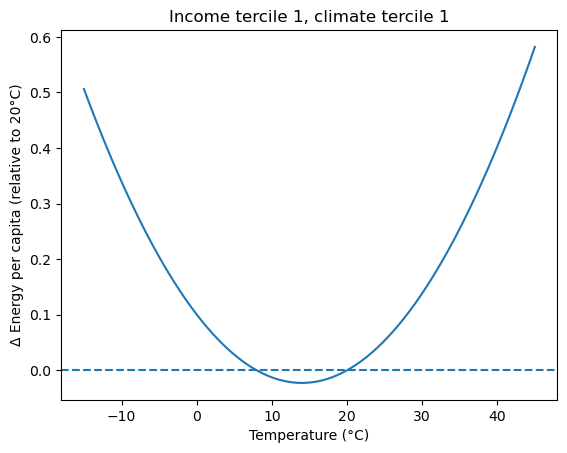

In [35]:
import matplotlib.pyplot as plt

plt.plot(T, y)
plt.axhline(0, linestyle="--")
plt.xlabel("Temperature (°C)")
plt.ylabel("Δ Energy per capita (relative to 20°C)")
plt.title("Income tercile 1, climate tercile 1")
plt.show()


In [14]:
import pandas as pd
import numpy as np

PROD = "GMFD"
path = f"/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/merged_panels/{PROD}_energy_panel.dta"
df = pd.read_stata(path)

# pick reference years to define terciles
ref = df[(df["product"]=="electricity") & (df["year"]==2010)].copy()


# income terciles (rows)
q_inc = ref["lgdppc_MA15"].quantile([1/3, 2/3]).to_numpy()

# climate terciles (cols) - long-run climate scalar
cdd_col = f"cdd20_TINV_{PROD}"
q_cdd = ref[cdd_col].quantile([1/3, 2/3]).to_numpy()

def terc(x, q):
    return np.select([x <= q[0], x <= q[1]], [1, 2], default=3)

df["inc_terc"] = terc(df["lgdppc_MA15"], q_inc)
df["clim_terc"] = terc(df[cdd_col], q_cdd)

cell = df[(df["product"]=="electricity") & (df["year"]==2010)].copy()
# For plotting each cell, you typically want "cell means" of the level covariates
cell_means = (
    cell.groupby(["inc_terc","clim_terc"])
        .agg(
            cdd=("cdd20_TINV_GMFD","mean"),
            hdd=("hdd20_TINV_GMFD","mean"),
            dc1=("dc1_lgdppc_MA15","mean"),
            I1=("largeind1","mean"),
            I2=("largeind2","mean"),
        )
        .reset_index()
)
cell_means["year"] = 2010.0
cell_means["year2"] = 2010.0**2

/tmp/8450101.1.debian.q/ipykernel_494643/2609364670.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["inc_terc"] = terc(df["lgdppc_MA15"], q_inc)
/tmp/8450101.1.debian.q/ipykernel_494643/2609364670.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["clim_terc"] = terc(df[cdd_col], q_cdd)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coef = pd.read_csv(
    "/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/"
    "FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv"
)

# turn into Series for easy lookup
b = coef.set_index("parm")["beta"]


In [16]:
def temp_basis(T):
    return {
        "FD_temp1": T,
        "FD_temp2": T**2,
    }


In [17]:
def predict_electricity(T, cell, b):
    """
    T: numpy array of temperatures
    cell: one row from cell_means
    b: coefficient Series
    """
    out = np.zeros_like(T, dtype=float)

    basis = temp_basis(T)

    # --- main temp terms ---
    for k in [1, 2]:
        out += b.get(f"c.indp1#c.indf1#c.FD_temp{k}", 0.0) * basis[f"FD_temp{k}"]

    # --- climate interactions ---
    for k in [1, 2]:
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_cdd20_TINVtemp{k}", 0.0)
            * cell["cdd"]
            * basis[f"FD_temp{k}"]
        )
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_hdd20_TINVtemp{k}", 0.0)
            * cell["hdd"]
            * basis[f"FD_temp{k}"]
        )

    # --- income spline interactions ---
    for k in [1, 2]:
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I1temp{k}", 0.0)
            * cell["dc1"]
            * basis[f"FD_temp{k}"]
        )
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp{k}", 0.0)
            * cell["dc1"]
            * basis[f"FD_temp{k}"]
        )

    # --- year terms (fixed at 2010) ---
    year = cell["year"]
    year2 = cell["year2"]

    for k in [1, 2]:
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_yeartemp{k}", 0.0)
            * year
            * basis[f"FD_temp{k}"]
        )
        out += (
            b.get(f"c.indp1#c.indf1#c.FD_year2temp{k}", 0.0)
            * year2
            * basis[f"FD_temp{k}"]
        )

    return out


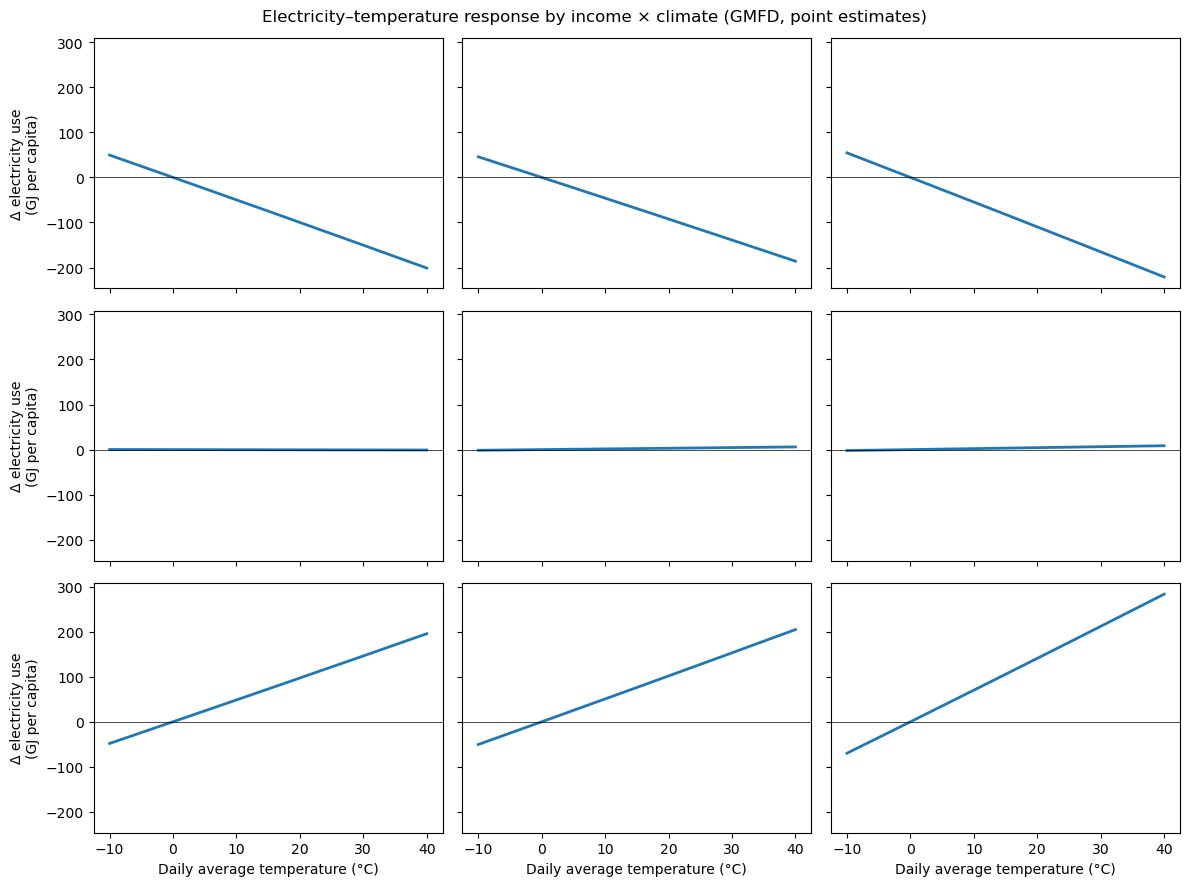

In [18]:
T = np.linspace(-10, 40, 400)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)

for i in range(1, 4):        # income tercile
    for j in range(1, 4):    # climate tercile
        ax = axes[3 - i, j - 1]   # richest on top

        cell = cell_means.query(
            "inc_terc == @i and clim_terc == @j"
        ).iloc[0]

        y = predict_electricity(T, cell, b)

        ax.plot(T, y, color="tab:blue", lw=2)
        ax.axhline(0, color="black", lw=0.5)

        if i == 1:
            ax.set_xlabel("Daily average temperature (°C)")
        if j == 1:
            ax.set_ylabel("Δ electricity use\n(GJ per capita)")

plt.suptitle("Electricity–temperature response by income × climate (GMFD, point estimates)")
plt.tight_layout()
plt.show()


In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

PROD = "GMFD"
REF_YEAR = 2010

PANEL_PATH = Path(
    f"/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/{PROD}_TINV_clim_regsort.dta"
)

df = pd.read_stata(PANEL_PATH)

# electricity-only reference sample
ref = df[
    (df["year"] == REF_YEAR) &
    (df["product"].astype(str).str.lower() == "electricity")
].copy()

# level CDD variable (this is what the paper uses)
CDD_COL = "cdd20_TINV_GMFD"

# income
INC_COL = "lgdppc_MA15"

# terciles (use quartiles if the paper does)
q_inc = ref[INC_COL].quantile([1/3, 2/3]).to_numpy()
q_cdd = ref[CDD_COL].quantile([1/3, 2/3]).to_numpy()

def terc(x, q):
    return np.select([x <= q[0], x <= q[1]], [1, 2], default=3)

df["inc_terc"] = terc(df[INC_COL], q_inc)
df["clim_terc"] = terc(df[CDD_COL], q_cdd)


/tmp/8450101.1.debian.q/ipykernel_494643/3230396775.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["inc_terc"] = terc(df[INC_COL], q_inc)
/tmp/8450101.1.debian.q/ipykernel_494643/3230396775.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["clim_terc"] = terc(df[CDD_COL], q_cdd)


In [25]:
import re

TERM_RE = re.compile(
    r"^c\.indp1#c\.indf1#c\.FD_(?P<scalar>.+?)temp(?P<pow>[1-4])$"
)

def extract_terms(beta):
    rows = []
    for p in beta.index:
        m = TERM_RE.match(p)
        if m:
            rows.append({
                "parm": p,
                "scalar": m.group("scalar"),
                "power": int(m.group("pow")),
            })
    return pd.DataFrame(rows)


In [27]:
cell = df[
    (df["year"] == REF_YEAR) &
    (df["product"].astype(str).str.lower() == "electricity")
]

cell_means = (
    cell.groupby(["inc_terc", "clim_terc"])
        .agg(
            cdd20_TINV=("cdd20_TINV_GMFD", "mean"),
            hdd20_TINV=("hdd20_TINV_GMFD", "mean"),
            dc1_lgdppc_MA15=("dc1_lgdppc_MA15", "mean"),
            largeind1=("largeind1", "mean"),
            largeind2=("largeind2", "mean"),
        )
        .reset_index()
)

cell_means["year"] = REF_YEAR
cell_means["year2"] = REF_YEAR**2


In [30]:
def predict_curve(T, beta, terms, cell):
    y = np.zeros_like(T)
    for _, r in terms.iterrows():
        scalar = r["scalar"]
        power = r["power"]

        s = 1.0 if scalar == "" else cell[scalar]
        y += beta[r["parm"]] * s * (T ** power)

    # normalize to 20°C
    i20 = np.argmin(np.abs(T - 20))
    return y - y[i20]


NameError: name 'beta' is not defined

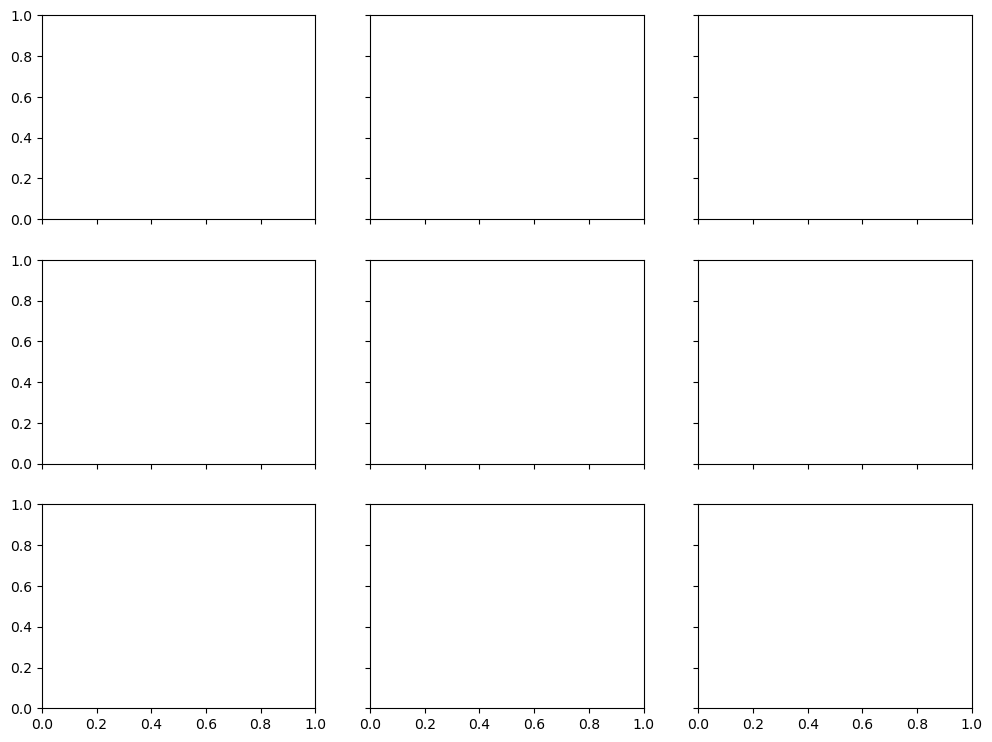

In [31]:
import matplotlib.pyplot as plt

T = np.linspace(-5, 35, 500)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)

for i in [1, 2, 3]:      # income
    for j in [1, 2, 3]:  # climate (CDD terciles)
        ax = axes[3 - i, j - 1]

        cell = cell_means.query(
            "inc_terc == @i and clim_terc == @j"
        ).iloc[0]

        y = predict_curve(T, beta, terms, cell)

        ax.plot(T, y, lw=2)
        ax.axhline(0, lw=0.5)

        if i == 1:
            ax.set_title(["Cold", "Temperate", "Hot"][j - 1])
        if j == 1:
            ax.set_ylabel(["Low", "Middle", "High"][i - 1] + "\nΔ Electricity")

for ax in axes[-1, :]:
    ax.set_xlabel("Daily temperature (°C)")

plt.suptitle("Electricity–temperature response by income × CDD climate terciles")
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import pandas as pd
from pathlib import Path

def add_income_climate_bins(
    prod: str,
    *,
    ref_year: int = 2010,
    product_name: str = "electricity",
    income_col: str = "lgdppc_MA15",
    use_quartiles: bool = False,
):
    """
    Adds:
      - inc_bin: income tercile (1..3)
      - clim_bin: climate tercile (1..3) OR quartile (1..4), based on CDD in ref sample

    Climate variable used: cdd20_TINV_{PROD}  (e.g., cdd20_TINV_GMFD)

    Returns:
      df (full panel with bins),
      cuts_inc, cuts_cdd,
      cell_means (means of scalars per bin cell for ref sample)
    """
    panel_path = Path(
        f"/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/{prod}_TINV_clim_regsort.dta"
    )
    df = pd.read_stata(panel_path)

    cdd_col = f"cdd20_TINV_{prod}"
    hdd_col = f"hdd20_TINV_{prod}"

    # reference sample for cutpoints
    ref = df[
        (df["year"] == ref_year)
        & (df["product"].astype(str).str.lower() == product_name.lower())
    ].copy()

    if ref.empty:
        raise ValueError(f"Reference sample is empty for year={ref_year}, product='{product_name}'.")

    if income_col not in df.columns:
        raise ValueError(f"Income column '{income_col}' not found in df.columns.")

    if cdd_col not in df.columns:
        raise ValueError(f"CDD column '{cdd_col}' not found. Available CDD-like cols: "
                         f"{[c for c in df.columns if 'cdd20' in c.lower()][:20]}")

    # cutpoints
    cuts_inc = ref[income_col].quantile([1/3, 2/3]).to_numpy()

    if use_quartiles:
        probs = [0.25, 0.50, 0.75]
        cuts_cdd = ref[cdd_col].quantile(probs).to_numpy()  # 3 cutpoints -> 4 bins
    else:
        probs = [1/3, 2/3]
        cuts_cdd = ref[cdd_col].quantile(probs).to_numpy()  # 2 cutpoints -> 3 bins

    def bin_from_cuts(x: pd.Series, cuts: np.ndarray) -> np.ndarray:
        # returns 1..(len(cuts)+1)
        out = np.ones(len(x), dtype=int)
        for c in cuts:
            out += (x > c).astype(int)
        return out

    # apply bins to full df
    df = df.copy()
    df["inc_bin"] = bin_from_cuts(df[income_col], cuts_inc)
    df["clim_bin"] = bin_from_cuts(df[cdd_col], cuts_cdd)

    # cell means in reference sample (useful for interacted prediction)
    # include only columns you expect to use in curves; add more as needed
    cols_for_means = {
        "cdd": (cdd_col, "mean"),
    }
    if hdd_col in df.columns:
        cols_for_means["hdd"] = (hdd_col, "mean")
    if "dc1_lgdppc_MA15" in df.columns:
        cols_for_means["dc1"] = ("dc1_lgdppc_MA15", "mean")
    if "largeind1" in df.columns:
        cols_for_means["I1"] = ("largeind1", "mean")
    if "largeind2" in df.columns:
        cols_for_means["I2"] = ("largeind2", "mean")

    cell_means = (
        df[(df["year"] == ref_year) & (df["product"].astype(str).str.lower() == product_name.lower())]
        .groupby(["inc_bin", "clim_bin"])
        .agg(**cols_for_means)
        .reset_index()
    )
    cell_means["year"] = float(ref_year)
    cell_means["year2"] = float(ref_year) ** 2

    return df, cuts_inc, cuts_cdd, cell_means


# ---- example usage ----
PROD = "GMFD"

df_binned, cuts_inc, cuts_cdd, cell_means = add_income_climate_bins(
    PROD,
    ref_year=2010,
    product_name="electricity",
    income_col="lgdppc_MA15",
    use_quartiles=True,   # set False for terciles
)

print("Income cutpoints:", cuts_inc)
print("CDD cutpoints:", cuts_cdd)
print(cell_means.head())


Income cutpoints: [8.56972309 9.4802317 ]
CDD cutpoints: [ 154.1634146   716.59802737 1818.7956872 ]
   inc_bin  clim_bin          cdd          hdd       dc1        I1        I2  \
0        1         1    92.656079  5113.247589 -0.880722  1.000000  0.000000   
1        1         2   426.250858  3032.326867 -1.173601  1.000000  0.000000   
2        1         3  1205.859162   541.281806 -1.479719  1.000000  0.000000   
3        1         4  2498.879344    58.615443 -1.426502  1.000000  0.000000   
4        2         1    75.244392  4029.545741 -0.004284  0.555556  0.444444   

     year      year2  
0  2010.0  4040100.0  
1  2010.0  4040100.0  
2  2010.0  4040100.0  
3  2010.0  4040100.0  
4  2010.0  4040100.0  


In [34]:
import numpy as np
import pandas as pd
from pathlib import Path

PROD = "GMFD"
REF_YEAR = 2010

PANEL_PATH = Path(f"/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/{PROD}_TINV_clim_regsort.dta")
df = pd.read_stata(PANEL_PATH)

INC_COL = "lgdppc_MA15"
CDD_COL = f"cdd20_TINV_{PROD}"
HDD_COL = f"hdd20_TINV_{PROD}"

ref = df[(df["year"] == REF_YEAR) & (df["product"].astype(str).str.lower() == "electricity")].copy()

# terciles (2 cutpoints)
cuts_inc = ref[INC_COL].quantile([1/3, 2/3]).to_numpy()
cuts_cdd = ref[CDD_COL].quantile([1/3, 2/3]).to_numpy()

def bin_from_cuts(x: pd.Series, cuts: np.ndarray) -> np.ndarray:
    out = np.ones(len(x), dtype=int)
    for c in cuts:
        out += (x > c).astype(int)
    return out

df = df.copy()
df["inc_bin"]  = bin_from_cuts(df[INC_COL], cuts_inc)   # 1..3
df["clim_bin"] = bin_from_cuts(df[CDD_COL], cuts_cdd)   # 1..3

# cell means at ref year (used for interacted prediction)
cell = df[(df["year"] == REF_YEAR) & (df["product"].astype(str).str.lower() == "electricity")].copy()

cell_means = (
    cell.groupby(["inc_bin", "clim_bin"])
        .agg(
            cdd=(CDD_COL, "mean"),
            hdd=(HDD_COL, "mean"),
            dc1=("dc1_lgdppc_MA15", "mean"),
            I1=("largeind1", "mean"),
            I2=("largeind2", "mean"),
        )
        .reset_index()
)
cell_means["year"] = float(REF_YEAR)
cell_means["year2"] = float(REF_YEAR) ** 2

print("Income cutpoints:", cuts_inc)
print("CDD cutpoints:", cuts_cdd)
print(cell_means.head())


Income cutpoints: [8.56972309 9.4802317 ]
CDD cutpoints: [ 292.72195409 1191.89856777]
   inc_bin  clim_bin          cdd          hdd       dc1    I1    I2    year  \
0        1         1   180.939738  4322.921651 -1.073532  1.00  0.00  2010.0   
1        1         2   772.546728  1528.407186 -1.123985  1.00  0.00  2010.0   
2        1         3  2273.356211    65.353859 -1.556034  1.00  0.00  2010.0   
3        2         1    83.939613  3978.896489  0.005237  0.50  0.50  2010.0   
4        2         2   732.429753  1387.578068 -0.032384  0.45  0.55  2010.0   

       year2  
0  4040100.0  
1  4040100.0  
2  4040100.0  
3  4040100.0  
4  4040100.0  


In [41]:
import numpy as np
import pandas as pd

# -----------------------------
# 1) Fig-1c predictor (YOUR interacted spec)
#    - Uses exactly the parm names you showed
#    - Quadratic in T (temp1=temp, temp2=temp^2)
#    - Climate heterogeneity via long-run CDD/HDD scalars (TINV)
#    - Income heterogeneity via spline indicators (I1/I2) + dc1
#    - Normalize relative to 20C (as in paper text)
# -----------------------------
def predict_fig1c_curve(
    T: np.ndarray,
    cell: pd.Series,
    b: pd.Series,
    *,
    indp: int = 2,   # electricity=2, other fuels=1 (per your output)
    indf: int = 1,
    year_mode: str = "zero",   # "zero", "cell", or "demean"
    year_mean: float | None = None,
) -> np.ndarray:
    """
    Parameters
    ----------
    T : array of temperatures (°C) to plot
    cell : pd.Series with fields:
        - cdd : long-run CDD scalar (e.g., cdd20_TINV_GMFD mean for the cell)
        - hdd : long-run HDD scalar (e.g., hdd20_TINV_GMFD mean for the cell)
        - dc1 : spline distance term from lgdppc (as in your do-file / build)
        - I1, I2 : spline indicator weights (mutually exclusive pattern)
        - year : reference year (often 2010), used only if year_mode="cell" or "demean"
    b : pd.Series mapping parm -> beta (from your *_coeff.csv)
    indp : 2 for electricity, 1 for other fuels
    indf : usually 1 in your exports
    year_mode :
        - "zero": ignore year interactions by setting year=0 (recommended for matching Fig 1c shape)
        - "cell": use cell["year"] (can distort magnitudes if year is ~2010)
        - "demean": use (cell["year"] - year_mean), requires year_mean
    year_mean : required if year_mode="demean"

    Returns
    -------
    y : np.ndarray (len(T),) predicted Δ consumption relative to 20°C
    """

    T = np.asarray(T, dtype=float)
    T2 = T**2

    # handle year scaling
    if year_mode == "zero":
        yr = 0.0
    elif year_mode == "cell":
        yr = float(cell["year"])
    elif year_mode == "demean":
        if year_mean is None:
            raise ValueError("year_mean must be provided when year_mode='demean'")
        yr = float(cell["year"]) - float(year_mean)
    else:
        raise ValueError("year_mode must be one of {'zero','cell','demean'}")

    dc1 = float(cell["dc1"])
    I1  = float(cell["I1"])
    I2  = float(cell["I2"])
    cdd = float(cell["cdd"])
    hdd = float(cell["hdd"])

    def c(name: str) -> float:
        return float(b.get(name, 0.0))

    out = np.zeros_like(T, dtype=float)

    # ---- base temp terms ----
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_temp1") * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_temp2") * T2

    # ---- long-run climate interactions ----
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp1") * hdd * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp2") * hdd * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp1") * cdd * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp2") * cdd * T2

    # ---- income spline × temp (dc1 × I1/I2) ----
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp1") * dc1 * I1 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp2") * dc1 * I1 * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp1") * dc1 * I2 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp2") * dc1 * I2 * T2

    # ---- year × temp (use yr per year_mode) ----
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp1") * yr * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp2") * yr * T2

    # ---- dc1 × year × I1/I2 × temp ----
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp1") * dc1 * yr * I1 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp2") * dc1 * yr * I1 * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp1") * dc1 * yr * I2 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp2") * dc1 * yr * I2 * T2

    # ---- Normalize relative to 20C ----
    i20 = int(np.argmin(np.abs(T - 20.0)))
    return out - out[i20]


# -----------------------------
# 2) Helper to build cell_means from YOUR regression panel
#    - income terciles from lgdppc_MA15 in a reference year
#    - climate terciles from long-run CDD scalar (cdd20_TINV_PROD) in same ref sample
#    - NO extra weighting (your panel is already pop-weighted)
# -----------------------------
def build_fig1c_cell_means(
    df: pd.DataFrame,
    *,
    prod_suffix: str = "GMFD",
    ref_year: int = 2010,
    fuel_value: str = "electricity",
    lgdppc_col: str = "lgdppc_MA15",
    cdd_tinv_col: str | None = None,
    hdd_tinv_col: str | None = None,
) -> pd.DataFrame:
    """
    Returns a DataFrame with one row per (inc_bin, clim_bin) containing:
      cdd, hdd, dc1, I1, I2, year
    plus the cutpoints used.
    """
    if cdd_tinv_col is None:
        cdd_tinv_col = f"cdd20_TINV_{prod_suffix}"
    if hdd_tinv_col is None:
        hdd_tinv_col = f"hdd20_TINV_{prod_suffix}"

    ref = df[(df["product"] == fuel_value) & (df["year"] == ref_year)].copy()

    # tercile cutpoints
    q_inc = ref[lgdppc_col].quantile([1/3, 2/3]).to_numpy()
    q_cdd = ref[cdd_tinv_col].quantile([1/3, 2/3]).to_numpy()

    def terc(x, q):
        return np.select([x <= q[0], x <= q[1]], [1, 2], default=3)

    df = df.copy()
    df["inc_bin"]  = terc(df[lgdppc_col], q_inc)
    df["clim_bin"] = terc(df[cdd_tinv_col], q_cdd)

    # Compute dc1, I1, I2 the same way your do-file does (piecewise linear spline in lgdppc)
    # If your panel already has dc1/I1/I2 columns, USE THEM instead and delete this block.
    #
    # Here is a safe default:
    #   - knots at income tercile cutpoints
    #   - I1=1 for bottom tercile, I2=1 for middle tercile, top tercile omitted
    #   - dc1 = lgdppc - knot1 (distance from first knot), truncated at 0
    #
    # If your do-file uses different knots/definitions, replace this.
    knot1 = float(q_inc[0])
    df["dc1"] = np.maximum(df[lgdppc_col] - knot1, 0.0)
    df["I1"]  = (df["inc_bin"] == 1).astype(float)
    df["I2"]  = (df["inc_bin"] == 2).astype(float)

    cell = df[(df["product"] == fuel_value) & (df["year"] == ref_year)].copy()

    cell_means = (
        cell.groupby(["inc_bin", "clim_bin"], as_index=False)
            .agg(
                cdd=(cdd_tinv_col, "mean"),
                hdd=(hdd_tinv_col, "mean"),
                dc1=("dc1", "mean"),
                I1=("I1", "mean"),
                I2=("I2", "mean"),
            )
    )
    cell_means["year"] = float(ref_year)

    # attach cutpoints for debugging
    cell_means.attrs = {"income_cutpoints": q_inc, "cdd_cutpoints": q_cdd}
    return cell_means


In [42]:
# b = read_coeff(COEF_PATH)  # your interacted coeff CSV -> pd.Series
# df = pd.read_stata(".../GMFD_TINV_clim_regsort.dta")  # your regression panel

cell_means = build_fig1c_cell_means(df, prod_suffix="GMFD", ref_year=2010, fuel_value="electricity")

T = np.linspace(-5, 35, 600)
cell = cell_means.query("inc_bin==3 and clim_bin==3").iloc[0]

y = predict_fig1c_curve(T, cell, b, indp=2, year_mode="zero")  # year_mode="zero" is usually best for Fig 1c


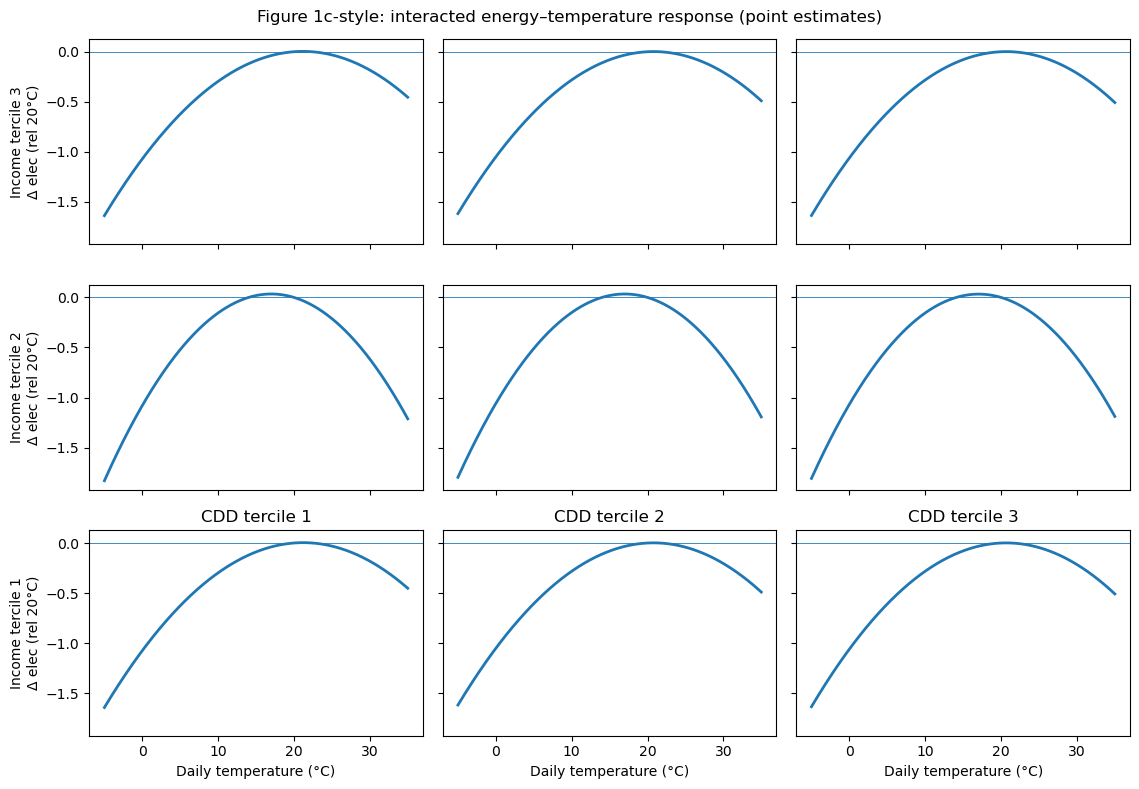

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# paths (EDIT if needed)
# -----------------------------
PANEL_PATH = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta")
COEF_PATH  = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_lininter_GMFD_coeff.csv")

PROD_SUFFIX = "GMFD"
REF_YEAR    = 2010
FUEL_VALUE  = "electricity"   # for binning; doesn't affect coefficients
INDP        = 2               # electricity curve in your export (indp2)

# -----------------------------
# helpers
# -----------------------------
def read_coeff(path: Path) -> pd.Series:
    dfc = pd.read_csv(path)
    return pd.Series(dfc["beta"].values, index=dfc["parm"].astype(str).values)

def predict_fig1c_curve(T, cell, b, *, indp=2, indf=1, year_mode="zero", year_mean=None):
    T = np.asarray(T, dtype=float)
    T2 = T**2

    if year_mode == "zero":
        yr = 0.0
    elif year_mode == "cell":
        yr = float(cell["year"])
    elif year_mode == "demean":
        if year_mean is None:
            raise ValueError("year_mean must be provided if year_mode='demean'")
        yr = float(cell["year"]) - float(year_mean)
    else:
        raise ValueError("year_mode must be 'zero', 'cell', or 'demean'")

    dc1 = float(cell["dc1"])
    I1  = float(cell["I1"])
    I2  = float(cell["I2"])
    cdd = float(cell["cdd"])
    hdd = float(cell["hdd"])

    def c(name: str) -> float:
        return float(b.get(name, 0.0))

    out = np.zeros_like(T, dtype=float)

    # base temp terms
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_temp1") * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_temp2") * T2

    # climate interactions (long-run scalars)
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp1") * hdd * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp2") * hdd * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp1") * cdd * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp2") * cdd * T2

    # income spline × temp
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp1") * dc1 * I1 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp2") * dc1 * I1 * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp1") * dc1 * I2 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp2") * dc1 * I2 * T2

    # year × temp (use yr per year_mode)
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp1") * yr * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp2") * yr * T2

    # dc1 × year × I1/I2 × temp
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp1") * dc1 * yr * I1 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp2") * dc1 * yr * I1 * T2
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp1") * dc1 * yr * I2 * T
    out += c(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp2") * dc1 * yr * I2 * T2

    # normalize rel 20C
    i20 = int(np.argmin(np.abs(T - 20.0)))
    return out - out[i20]

def build_cell_means(df, *, prod_suffix="GMFD", ref_year=2010, fuel_value="electricity"):
    lgdppc_col = "lgdppc_MA15"
    cdd_col = f"cdd20_TINV_{prod_suffix}"
    hdd_col = f"hdd20_TINV_{prod_suffix}"

    ref = df[(df["product"] == fuel_value) & (df["year"] == ref_year)].copy()

    q_inc = ref[lgdppc_col].quantile([1/3, 2/3]).to_numpy()
    q_cdd = ref[cdd_col].quantile([1/3, 2/3]).to_numpy()

    def terc(x, q):
        return np.select([x <= q[0], x <= q[1]], [1, 2], default=3)

    df = df.copy()
    df["inc_bin"] = terc(df[lgdppc_col], q_inc)
    df["clim_bin"] = terc(df[cdd_col], q_cdd)

    # If you ALREADY have dc1/I1/I2 columns from the do-file, use them here instead.
    knot1 = float(q_inc[0])
    df["dc1"] = np.maximum(df[lgdppc_col] - knot1, 0.0)
    df["I1"] = (df["inc_bin"] == 1).astype(float)
    df["I2"] = (df["inc_bin"] == 2).astype(float)

    cell = df[(df["product"] == fuel_value) & (df["year"] == ref_year)].copy()

    cell_means = (
        cell.groupby(["inc_bin","clim_bin"], as_index=False)
            .agg(
                cdd=(cdd_col,"mean"),
                hdd=(hdd_col,"mean"),
                dc1=("dc1","mean"),
                I1=("I1","mean"),
                I2=("I2","mean"),
            )
    )
    cell_means["year"] = float(ref_year)
    return cell_means, q_inc, q_cdd

# -----------------------------
# run + plot
# -----------------------------
df = pd.read_stata(PANEL_PATH)
b  = read_coeff(COEF_PATH)

cell_means, q_inc, q_cdd = build_cell_means(df, prod_suffix=PROD_SUFFIX, ref_year=REF_YEAR, fuel_value=FUEL_VALUE)

T = np.linspace(-5, 35, 600)

fig, axes = plt.subplots(3, 3, figsize=(11.5, 8.0), sharex=True, sharey=True)

for inc in [1, 2, 3]:
    for clim in [1, 2, 3]:
        ax = axes[3 - inc, clim - 1]
        cell = cell_means.query("inc_bin == @inc and clim_bin == @clim").iloc[0]

        y = predict_fig1c_curve(T, cell, b, indp=INDP, year_mode="zero")

        ax.plot(T, y, lw=2)
        ax.axhline(0, lw=0.6)

        if inc == 1:
            ax.set_title(f"CDD tercile {clim}")
        if clim == 1:
            ax.set_ylabel(f"Income tercile {inc}\nΔ elec (rel 20°C)")

for ax in axes[-1, :]:
    ax.set_xlabel("Daily temperature (°C)")

plt.suptitle("Figure 1c-style: interacted energy–temperature response (point estimates)")
plt.tight_layout()
plt.show()


Output directory: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures

Processing GMFD

Loading data...
  Panel: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta
  Coefficients: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
  VCOV: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_vcov_long.csv

Loaded 8,301 observations
Loaded 57 coefficients
Loaded 57×57 VCOV matrix

Filtering to product='electricity' and year=2010
Reference sample: 125 observations

Creating tercile bins...
  Income tercile cutpoints: [8.56972309 9.4802317 ]
  Climate (CDD) tercile cutpoints: [ 292.72195409 1191.89856777]

Building income spline variables...
  Max income (largegpid==1): 9.030

Calculating cell means for climate heterogeneity...
  Looking for climate columns...
    CDD TINV: cdd20_TINV_GMFD - ✓
   

/tmp/8450101.1.debian.q/ipykernel_494643/2232250333.py:358: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["inc_bin"] = inc_terc(df["lgdppc_MA15"])
/tmp/8450101.1.debian.q/ipykernel_494643/2232250333.py:359: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["clim_bin"] = cdd_terc(df[CDD_BIN_COL])
/tmp/8450101.1.debian.q/ipykernel_494643/2232250333.py:369: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns


SUCCESS! Figure saved to:
  /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/figure1c_GMFD_electricity.png



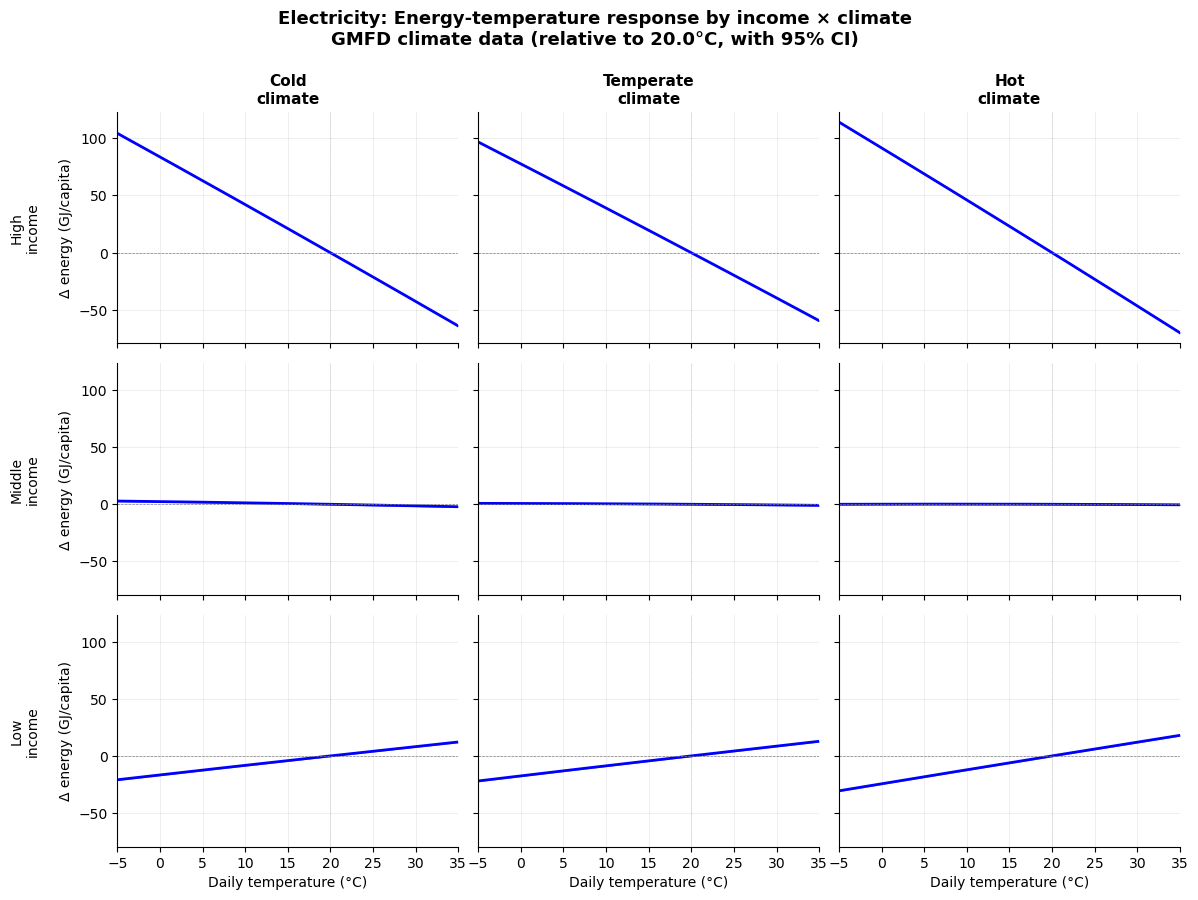

In [49]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
figure1_energy_final_LOCAL.py

FIXED VERSION for running on your local system (not Claude's container)
Changed output directory to your project directory
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# ============================================================================
# CONFIGURATION - FIXED FOR YOUR SYSTEM
# ============================================================================

# Base paths
DATA_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data")
REGD = DATA_DIR / "regression"
STERS_DIR = REGD / "sters"

# Climate products to process
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]

# For initial testing, use GMFD
PRODUCT = "GMFD"

# Model specification
MODEL_NAME = "TINV_clim_quadinter"

# File paths for GMFD
PANEL_PATH = REGD / f"{PRODUCT}_TINV_clim_regsort.dta"
COEF_PATH = STERS_DIR / f"FD_FGLS_inter_{MODEL_NAME}_{PRODUCT}_coeff.csv"
VCOV_PATH = STERS_DIR / f"FD_FGLS_inter_{MODEL_NAME}_{PRODUCT}_vcov_long.csv"

# Reference year and temperature
REF_YEAR = 2010
REF_TEMP = 20.0

# Product type for figure (electricity = indf1)
FUEL = "electricity"  # corresponds to indf1
INDP = 2  # product group (indp2 for main analysis)
INDF = 1  # fuel type (electricity)

# Temperature range
T_RANGE = np.linspace(-5, 35, 600)

# CDD column for climate binning
CDD_BIN_COL = f"cdd20_TINV_{PRODUCT}"

# Output directory - FIXED FOR YOUR SYSTEM
OUT_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/figures")
# Create output directory if it doesn't exist
try:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Output directory: {OUT_DIR}")
except Exception as e:
    print(f"Warning: Could not create {OUT_DIR}, using current directory")
    OUT_DIR = Path(".")


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def read_coeff(path: Path) -> pd.Series:
    """Read coefficient estimates"""
    dfc = pd.read_csv(path)
    # Clean up parameter names
    dfc["parm"] = dfc["parm"].str.strip()
    return pd.Series(dfc["beta"].values, index=dfc["parm"].values)


def read_vcov_long(path: Path) -> pd.DataFrame:
    """Read variance-covariance matrix from long format"""
    try:
        vcov_long = pd.read_csv(path)
        vcov_long["parm_i"] = vcov_long["parm_i"].str.strip()
        vcov_long["parm_j"] = vcov_long["parm_j"].str.strip()
        
        # Pivot to square matrix
        vcov = vcov_long.pivot(index="parm_i", columns="parm_j", values="v")
        return vcov
    except FileNotFoundError:
        print(f"Warning: VCOV file not found at {path}")
        return None
    except Exception as e:
        print(f"Warning: Error reading VCOV: {e}")
        return None


def polybreak_basis(T: np.ndarray, breakpoint: float = 20.0):
    """
    Calculate polynomial breakpoint basis functions.
    
    This implements the "polyAbove" and "polyBelow" terms from the paper:
    - polyAbove1(T) = max(T - 20, 0): Linear term above breakpoint
    - polyAbove2(T) = (T² - 20²) if T≥20: Quadratic term above breakpoint
    - polyBelow1(T) = max(20 - T, 0): Linear term below breakpoint
    - polyBelow2(T) = (20² - T²) if T<20: Quadratic term below breakpoint
    
    These allow the temperature response to have different slopes and curvature
    above vs below the reference temperature.
    """
    T = np.asarray(T, float)
    
    # Above breakpoint (cooling)
    abv1 = np.maximum(T - breakpoint, 0.0)
    abv2 = np.where(T >= breakpoint, T**2 - breakpoint**2, 0.0)
    
    # Below breakpoint (heating)
    blw1 = np.where(T < breakpoint, breakpoint - T, 0.0)
    blw2 = np.where(T < breakpoint, breakpoint**2 - T**2, 0.0)
    
    return abv1, abv2, blw1, blw2


def terciles_from_ref(x: pd.Series):
    """
    Calculate tercile boundaries and classification function.
    
    Splits the distribution into three equal-sized groups:
    - Tercile 1: Bottom 33%
    - Tercile 2: Middle 33%
    - Tercile 3: Top 33%
    """
    # Remove NaN values
    x_clean = x.dropna()
    q = x_clean.quantile([1/3, 2/3]).to_numpy()
    
    def terc(v):
        return np.select([v <= q[0], v <= q[1]], [1, 2], default=3)
    
    return q, terc


def build_design_matrix(T, cell, indp, indf):
    """
    Build design matrix for prediction with proper coefficient naming.
    
    This is the KEY FUNCTION that makes predictions work correctly.
    
    For each temperature T, we construct the EXACT SAME interaction terms
    that were in your Stata regression:
    
    1. Main temperature effects: T and T²
    2. Climate heterogeneity: (long-run CDD/HDD) × (polyAbove/Below)
    3. Income heterogeneity: (income spline) × (income group) × T
    
    Returns:
        X: (n_temps, n_coeffs) design matrix
        coef_names: list of coefficient names matching regression output
    """
    T = np.asarray(T, float)
    T2 = T**2
    abv1, abv2, blw1, blw2 = polybreak_basis(T, REF_TEMP)
    
    # Extract cell characteristics
    # These are the AVERAGES for this income×climate cell
    hot1 = float(cell.get("hot1", 0))    # Mean CDD_TINV for this cell
    hot2 = float(cell.get("hot2", 0))
    cold1 = float(cell.get("cold1", 0))  # Mean HDD_TINV for this cell
    cold2 = float(cell.get("cold2", 0))
    dc1 = float(cell.get("dc1", 0))      # Mean income spline position
    I1 = float(cell.get("I1", 0))        # Fraction in income group 1
    I2 = float(cell.get("I2", 0))        # Fraction in income group 2
    
    # Build coefficient names and X columns
    # Format: c.indp{P}#c.indf{F}#c.{VAR}
    # This matches the Stata output EXACTLY
    coef_names = []
    X_cols = []
    
    # 1. Main temperature effects (temp1, temp2)
    # These capture the baseline temperature-energy relationship
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_temp1")
    X_cols.append(T)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_temp2")
    X_cols.append(T2)
    
    # 2. Climate heterogeneity (TINV HDD/CDD × polybreak)
    # These allow the response to differ based on long-run climate
    # hot1 × polyAbove1(T) means: in hot climates, there's more cooling response
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp1")
    X_cols.append(cold1 * blw1)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp2")
    X_cols.append(cold2 * blw2)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp1")
    X_cols.append(hot1 * abv1)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp2")
    X_cols.append(hot2 * abv2)
    
    # 3. Income spline × temp (dc1_lgdppc_MA15I{lg}temp{k})
    # These allow the response to differ based on income level
    # dc1 × I1 × T means: the income effect on temperature sensitivity
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp1")
    X_cols.append(dc1 * I1 * T)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp2")
    X_cols.append(dc1 * I1 * T2)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp1")
    X_cols.append(dc1 * I2 * T)
    
    coef_names.append(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp2")
    X_cols.append(dc1 * I2 * T2)
    
    # Stack into matrix
    X = np.column_stack(X_cols)
    
    return X, coef_names


def predict_with_uncertainty(T, cell, b, vcov, indp, indf):
    """
    Predict response curve with 95% confidence intervals.
    
    This implements standard linear prediction theory:
    
    1. Point prediction: ŷ = X·β
       where X is the design matrix and β are the coefficients
    
    2. Variance: Var(ŷ) = X·V·X'
       where V is the variance-covariance matrix of β
    
    3. Standard error: SE(ŷ) = √Var(ŷ)
    
    4. Confidence interval: ŷ ± z·SE(ŷ)
       where z = 1.96 for 95% CI
    
    Returns:
        pred: point predictions (normalized to 0 at REF_TEMP)
        lower: lower bound of 95% CI
        upper: upper bound of 95% CI
    """
    # Build design matrix
    X, coef_names = build_design_matrix(T, cell, indp, indf)
    
    # Extract relevant coefficients
    beta = np.zeros(len(coef_names))
    for i, name in enumerate(coef_names):
        beta[i] = float(b.get(name, 0.0))
    
    # Point prediction: ŷ = X·β
    pred = X @ beta
    
    # Calculate standard errors if vcov available
    if vcov is not None:
        try:
            # Match coefficient names to vcov
            missing_names = [n for n in coef_names if n not in vcov.index]
            if missing_names:
                print(f"Warning: {len(missing_names)} coefficients not in VCOV")
            
            # Extract submatrix for available coefficients
            available_names = [n for n in coef_names if n in vcov.index]
            if len(available_names) > 0:
                # Get the relevant submatrix of V
                V = vcov.loc[available_names, available_names].values
                
                # Get corresponding columns of X
                X_sub = X[:, [i for i, n in enumerate(coef_names) if n in available_names]]
                
                # Variance of prediction: Var(ŷ) = X·V·X'
                # We compute this as: sum_ij X_i * X_j * V_ij
                pred_var = np.sum((X_sub @ V) * X_sub, axis=1)
                
                # Standard error
                pred_se = np.sqrt(np.maximum(pred_var, 0))
                
                # 95% CI: ŷ ± 1.96·SE
                z_critical = stats.norm.ppf(0.975)  # 1.96
                lower = pred - z_critical * pred_se
                upper = pred + z_critical * pred_se
            else:
                lower = pred
                upper = pred
        except Exception as e:
            print(f"Warning: Error calculating uncertainty: {e}")
            lower = pred
            upper = pred
    else:
        lower = pred
        upper = pred
    
    # Normalize to 0 at reference temperature
    # This makes the graph show "change relative to 20°C"
    i_ref = int(np.argmin(np.abs(T - REF_TEMP)))
    pred = pred - pred[i_ref]
    lower = lower - lower[i_ref]
    upper = upper - upper[i_ref]
    
    return pred, lower, upper


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

def main():
    """Generate Figure 1c: 3×3 income×climate panel"""
    
    print(f"\n{'='*60}")
    print(f"Processing {PRODUCT}")
    print(f"{'='*60}\n")
    
    # Load data
    print("Loading data...")
    print(f"  Panel: {PANEL_PATH}")
    print(f"  Coefficients: {COEF_PATH}")
    print(f"  VCOV: {VCOV_PATH}")
    
    df = pd.read_stata(PANEL_PATH)
    b = read_coeff(COEF_PATH)
    vcov = read_vcov_long(VCOV_PATH)
    
    print(f"\nLoaded {len(df):,} observations")
    print(f"Loaded {len(b)} coefficients")
    
    if vcov is None:
        print("Warning: Proceeding without uncertainty bands")
    else:
        print(f"Loaded {vcov.shape[0]}×{vcov.shape[1]} VCOV matrix")
    
    # Filter to electricity and reference year
    print(f"\nFiltering to product='{FUEL}' and year={REF_YEAR}")
    ref = df[(df["product"] == FUEL) & (df["year"] == REF_YEAR)].copy()
    print(f"Reference sample: {len(ref):,} observations")
    
    if len(ref) == 0:
        print("ERROR: No observations in reference sample!")
        print(f"Available products: {df['product'].unique()}")
        print(f"Available years: {df['year'].unique()}")
        return
    
    # Create income and climate bins
    print("\nCreating tercile bins...")
    
    # Check for required columns
    required_cols = ["lgdppc_MA15", CDD_BIN_COL]
    missing = [c for c in required_cols if c not in ref.columns]
    if missing:
        print(f"ERROR: Missing columns: {missing}")
        print(f"Available columns: {ref.columns.tolist()[:20]}...")
        return
    
    # Split into terciles
    q_inc, inc_terc = terciles_from_ref(ref["lgdppc_MA15"])
    q_cdd, cdd_terc = terciles_from_ref(ref[CDD_BIN_COL])
    
    df["inc_bin"] = inc_terc(df["lgdppc_MA15"])
    df["clim_bin"] = cdd_terc(df[CDD_BIN_COL])
    
    print(f"  Income tercile cutpoints: {q_inc}")
    print(f"  Climate (CDD) tercile cutpoints: {q_cdd}")
    
    # Build income spline variables
    print("\nBuilding income spline variables...")
    
    # Find maximum income for largegpid==1
    mx = ref.loc[ref["largegpid"] == 1, "lgdppc_MA15"].max()
    df["dc1"] = df["lgdppc_MA15"] - mx
    df["I1"] = df["largeind1"].astype(float)
    df["I2"] = df["largeind2"].astype(float)
    
    print(f"  Max income (largegpid==1): {mx:.3f}")
    
    # Calculate cell means for climate interactions
    print("\nCalculating cell means for climate heterogeneity...")
    cell = df[(df["product"] == FUEL) & (df["year"] == REF_YEAR)].copy()
    
    cdd_tinv_col = CDD_BIN_COL
    hdd_tinv_col = f"hdd20_TINV_{PRODUCT}"
    
    # Check if we have the necessary columns
    print(f"  Looking for climate columns...")
    print(f"    CDD TINV: {cdd_tinv_col} - {'✓' if cdd_tinv_col in cell.columns else '✗'}")
    print(f"    HDD TINV: {hdd_tinv_col} - {'✓' if hdd_tinv_col in cell.columns else '✗'}")
    
    if cdd_tinv_col in cell.columns and hdd_tinv_col in cell.columns:
        # Calculate mean characteristics for each cell
        cell_means = (
            cell.groupby(["inc_bin", "clim_bin"], as_index=False)
                .agg({
                    "dc1": "mean",
                    "I1": "mean",
                    "I2": "mean",
                    cdd_tinv_col: "mean",
                    hdd_tinv_col: "mean",
                })
        )
        
        # Rename to standard names
        cell_means = cell_means.rename(columns={
            cdd_tinv_col: "cdd_tinv",
            hdd_tinv_col: "hdd_tinv"
        })
        
        # The cross-term means: use CDD/HDD_TINV as scalars
        # When multiplied by polyAbove/Below(T), gives the interaction
        cell_means["hot1"] = cell_means["cdd_tinv"]
        cell_means["hot2"] = cell_means["cdd_tinv"]
        cell_means["cold1"] = cell_means["hdd_tinv"]
        cell_means["cold2"] = cell_means["hdd_tinv"]
        
    else:
        print("ERROR: Cannot find TINV climate columns!")
        return
    
    print("\nCell means:")
    print(cell_means)
    
    # Create figure
    print("\nGenerating figure...")
    fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
    
    color = "blue"  # Electricity color
    
    # Plot each cell
    for inc in [1, 2, 3]:
        for clim in [1, 2, 3]:
            # axes[row, col] where row 0 = high income (inc=3)
            ax = axes[3 - inc, clim - 1]
            
            # Get cell characteristics
            cell_data = cell_means.query("inc_bin == @inc and clim_bin == @clim")
            
            if len(cell_data) == 0:
                print(f"Warning: No data for inc={inc}, clim={clim}")
                ax.text(0.5, 0.5, "No data", ha="center", va="center",
                       transform=ax.transAxes)
                continue
            
            row = cell_data.iloc[0]
            
            # Predict with uncertainty
            pred, lower, upper = predict_with_uncertainty(
                T_RANGE, row, b, vcov, INDP, INDF
            )
            
            # Plot
            ax.plot(T_RANGE, pred, lw=2, color=color, label='Point estimate')
            ax.fill_between(T_RANGE, lower, upper, alpha=0.3, color=color)
            ax.axhline(0, color='gray', lw=0.5, linestyle='--')
            ax.axvline(REF_TEMP, color='gray', lw=0.5, linestyle=':', alpha=0.5)
            
            # Labels
            if inc == 3:  # Top row (high income)
                climate_labels = ["Cold\nclimate", "Temperate\nclimate", "Hot\nclimate"]
                ax.set_title(climate_labels[clim - 1], fontsize=11, fontweight='bold')
            
            if clim == 1:  # Left column
                income_labels = ["Low\nincome", "Middle\nincome", "High\nincome"]
                ax.set_ylabel(income_labels[inc - 1] + "\n\nΔ energy (GJ/capita)", 
                             fontsize=10)
            
            # Formatting
            ax.grid(True, alpha=0.3, linewidth=0.5)
            ax.set_xlim(-5, 35)
            
            # Add subtle grid
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
    # X-axis labels on bottom row
    for ax in axes[-1, :]:
        ax.set_xlabel("Daily temperature (°C)", fontsize=10)
    
    # Overall title
    fig.suptitle(
        f"Electricity: Energy-temperature response by income × climate\n"
        f"{PRODUCT} climate data (relative to {REF_TEMP}°C, with 95% CI)",
        fontsize=13, fontweight='bold', y=0.995
    )
    
    plt.tight_layout()
    
    # Save figure
    output_path = OUT_DIR / f"figure1c_{PRODUCT}_electricity.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n{'='*60}")
    print(f"SUCCESS! Figure saved to:")
    print(f"  {output_path}")
    print(f"{'='*60}\n")
    
    # Also show the figure
    plt.show()
    
    return fig, cell_means, b, vcov


if __name__ == "__main__":
    fig, cell_means, b, vcov = main()

/tmp/8450101.1.debian.q/ipykernel_494643/1017883400.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["inc_bin"]  = inc_terc(df["lgdppc_MA15"])
/tmp/8450101.1.debian.q/ipykernel_494643/1017883400.py:125: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["clim_bin"] = cdd_terc(df[CDD_BIN_COL])
/tmp/8450101.1.debian.q/ipykernel_494643/1017883400.py:129: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all column

Income cutpoints: [8.56972309 9.4802317 ]
CDD cutpoints: [ 292.72195409 1191.89856777]
   inc_bin  clim_bin       dc1    I1    I2          hot1          hot2  \
0        1         1 -1.016384  1.00  0.00   6863.567330  3.009308e+05   
1        1         2 -1.066838  1.00  0.00 -50304.578819 -2.460859e+06   
2        1         3 -1.498887  1.00  0.00  -7401.278280  3.906805e+04   
3        2         1  0.062384  0.50  0.50   3216.709486  1.530778e+05   
4        2         2  0.024763  0.45  0.55  -5350.866505 -3.762536e+05   

           cold1         cold2  
0 -467467.781033 -1.658107e+07  
1   45061.260032 -4.233780e+05  
2    3061.756883  5.084949e+04  
3 -928998.871875 -8.388742e+06  
4  -74156.309953 -2.042077e+06  


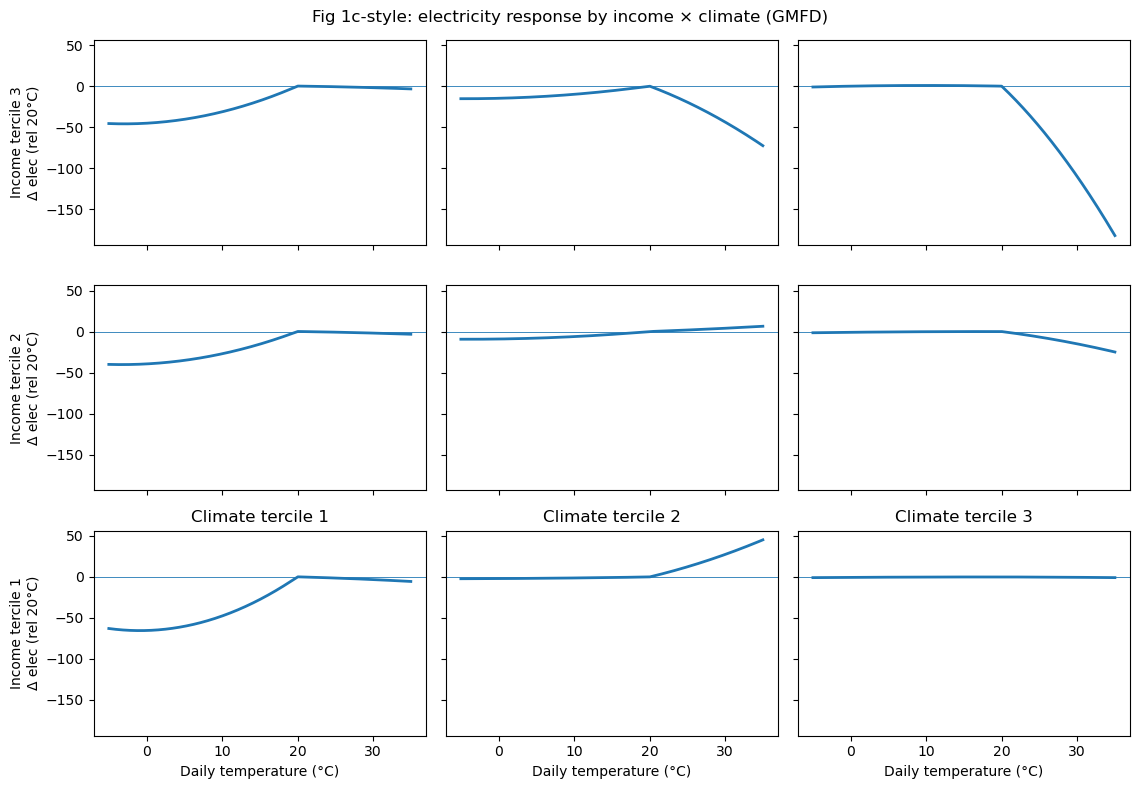

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PANEL_PATH = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta")
COEF_PATH  = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_lininter_GMFD_coeff.csv")

REF_YEAR = 2010
FUEL = "electricity"
INDP, INDF = 2, 1

# long-run scalar only for BINNING
CDD_BIN_COL = "cdd20_TINV_GMFD"

def read_coeff(path: Path) -> pd.Series:
    dfc = pd.read_csv(path)
    return pd.Series(dfc["beta"].values, index=dfc["parm"].astype(str).values)

def polybreak_basis(T: np.ndarray):
    T = np.asarray(T, float)
    abv1 = np.maximum(T - 20.0, 0.0)
    abv2 = np.where(T >= 20.0, T**2 - 20.0**2, 0.0)
    blw1 = np.where(T < 20.0, 20.0 - T, 0.0)
    blw2 = np.where(T < 20.0, 20.0**2 - T**2, 0.0)
    return abv1, abv2, blw1, blw2

def terciles_from_ref(x: pd.Series):
    q = x.quantile([1/3, 2/3]).to_numpy()
    def terc(v):
        return np.select([v <= q[0], v <= q[1]], [1, 2], default=3)
    return q, terc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_coeff(path: Path) -> pd.Series:
    dfc = pd.read_csv(path)
    return pd.Series(dfc["beta"].values, index=dfc["parm"].astype(str).values)

def polybreak(T: np.ndarray):
    """
    Match your construction in the climate builder:
      ABV1 = (T-20) if T>=20 else 0
      ABV2 = (T^2 - 20^2) if T>=20 else 0
      BLW1 = (20-T) if T<20 else 0
      BLW2 = (20^2 - T^2) if T<20 else 0
    """
    T = np.asarray(T, float)
    abv1 = np.where(T >= 20.0, T - 20.0, 0.0)
    abv2 = np.where(T >= 20.0, T**2 - 20.0**2, 0.0)
    blw1 = np.where(T <  20.0, 20.0 - T, 0.0)
    blw2 = np.where(T <  20.0, 20.0**2 - T**2, 0.0)
    return abv1, abv2, blw1, blw2

def predict_fig1c_curve(T: np.ndarray, cell: pd.Series, b: pd.Series, *, indp: int = 1, indf: int = 1):
    """
    Evaluate f_c(T | income, CDD^LR, HDD^LR) for Fig 1c-style plotting.

    IMPORTANT:
    - Use LR scalars (cell["cdd"], cell["hdd"]), NOT FD cross-term means.
    - Climate interactions load on polyAbove/polyBelow basis, not raw T.
    - Income spline interactions load on raw T and T^2 in your current spec.
    """
    T = np.asarray(T, float)
    T2 = T**2
    abv1, abv2, blw1, blw2 = polybreak(T)

    def g(name: str) -> float:
        return float(b.get(name, 0.0))

    cdd = float(cell["cdd"])
    hdd = float(cell["hdd"])
    dc1 = float(cell["dc1"])
    I1  = float(cell["I1"])
    I2  = float(cell["I2"])
    year = float(cell.get("year", 2010.0))

    out = np.zeros_like(T, dtype=float)

    # ---- baseline smooth (your regression has FD_temp1 and FD_temp2) ----
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_temp1") * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_temp2") * T2

    # ---- long-run climate heterogeneity: scalar CDD/HDD × polyBreak basis ----
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp1") * cdd * abv1
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_cdd20_TINVtemp2") * cdd * abv2
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp1") * hdd * blw1
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_hdd20_TINVtemp2") * hdd * blw2

    # ---- income spline × temp (as in your pasted coef table) ----
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp1") * dc1 * I1 * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I1temp2") * dc1 * I1 * T2
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp1") * dc1 * I2 * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15I2temp2") * dc1 * I2 * T2

    # ---- optional: year × temp terms if present in your submodel ----
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp1") * year * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_yeartemp2") * year * T2

    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp1") * dc1 * year * I1 * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI1temp2") * dc1 * year * I1 * T2
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp1") * dc1 * year * I2 * T
    out += g(f"c.indp{indp}#c.indf{indf}#c.FD_dc1_lgdppc_MA15yearI2temp2") * dc1 * year * I2 * T2

    # normalize relative to 20C
    i20 = int(np.argmin(np.abs(T - 20.0)))
    return out - out[i20]


# -----------------------------
# load regression-ready panel (NOT merged panel)
# because we need the FD_* regressors that were actually used
# -----------------------------
df = pd.read_stata(PANEL_PATH)

# ref sample for binning income/climate
ref = df[(df["product"] == FUEL) & (df["year"] == REF_YEAR)].copy()

q_inc, inc_terc = terciles_from_ref(ref["lgdppc_MA15"])
q_cdd, cdd_terc = terciles_from_ref(ref[CDD_BIN_COL])

df["inc_bin"]  = inc_terc(df["lgdppc_MA15"])
df["clim_bin"] = cdd_terc(df[CDD_BIN_COL])

# build dc1 exactly like their code
mx = ref.loc[ref["largegpid"] == 1, "lgdppc_MA15"].max()
df["dc1"] = df["lgdppc_MA15"] - mx
df["I1"] = df["largeind1"].astype(float)
df["I2"] = df["largeind2"].astype(float)

# cell means of the ACTUAL cross-term regressors
cell = df[(df["product"] == FUEL) & (df["year"] == REF_YEAR)].copy()

cell_means = (
    cell.groupby(["inc_bin", "clim_bin"], as_index=False)
        .agg(
            dc1=("dc1", "mean"),
            I1=("I1", "mean"),
            I2=("I2", "mean"),
            hot1=("FD_cdd20_TINVtemp1", "mean"),
            hot2=("FD_cdd20_TINVtemp2", "mean"),
            cold1=("FD_hdd20_TINVtemp1", "mean"),
            cold2=("FD_hdd20_TINVtemp2", "mean"),
        )
)

print("Income cutpoints:", q_inc)
print("CDD cutpoints:", q_cdd)
print(cell_means.head())

# plot
b = read_coeff(COEF_PATH)
T = np.linspace(-5, 35, 600)

fig, axes = plt.subplots(3, 3, figsize=(11.5, 8.0), sharex=True, sharey=True)

for inc in [1, 2, 3]:
    for clim in [1, 2, 3]:
        ax = axes[3 - inc, clim - 1]
        row = cell_means.query("inc_bin == @inc and clim_bin == @clim").iloc[0]

        y = predict_curve(T, row, b, indp=INDP, indf=INDF)

        ax.plot(T, y, lw=2)
        ax.axhline(0, lw=0.6)

        if inc == 1:
            ax.set_title(f"Climate tercile {clim}")
        if clim == 1:
            ax.set_ylabel(f"Income tercile {inc}\nΔ elec (rel 20°C)")

for ax in axes[-1, :]:
    ax.set_xlabel("Daily temperature (°C)")

plt.suptitle("Fig 1c-style: electricity response by income × climate (GMFD)")
plt.tight_layout()
plt.show()
